In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("ALS.txt",sep=r"\s+")
df.head()

,testset,dFRS,Onset.Delta,Symptom.Speech,Symptom.WEAKNESS,Symptom.OTHER,Symptom.Swallowing,Symptom.GAIT_CHANGES,Symptom.Atrophy,Symptom.Cramps,...,max.slope.bp.systolic,min.slope.bp.systolic,last.slope.bp.systolic,mean.slope.bp.systolic,num.slope.bp.systolic.visits,sum.slope.bp.systolic,first.slope.bp.systolic.date,meansquares.slope.bp.systolic,sd.slope.bp.systolic,slope.bp.systolic.slope
0,True,-0.915388,-1181,1,0,0,1,0,0,0,...,0.981828,-8.300909,0.000000,-2.439694,3,-7.319081,5.5,23.289693,4.163843,5.003010
1,True,-0.107931,-1324,0,1,0,0,0,0,0,...,0.000000,-9.818280,-9.818280,-4.909140,2,-9.818280,18.0,48.199307,4.909140,-8.920469
2,True,-0.557448,-1061,0,0,0,0,0,0,0,...,6.522143,-5.533939,6.522143,0.494102,2,0.988203,11.0,36.581416,6.028041,14.677878
3,True,-0.296461,-1736,0,1,0,0,0,0,0,...,55.800556,-87.928148,10.145556,-8.606468,7,-60.245275,4.5,1842.174361,42.048818,41.458842
4,True,-1.087024,-354,1,0,0,0,0,0,0,...,6.917424,-10.870238,6.917424,-1.317605,3,-3.952814,6.0,55.337611,7.321307,3.759702


In [ ]:
print(df.shape)

(1822, 371)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1822 entries, 0 to 1821
Columns: 371 entries, testset to slope.bp.systolic.slope
dtypes: bool(1), float64(226), int64(144)
memory usage: 5.1 MB
None


In [ ]:
print(df.describe())

              dFRS  Onset.Delta  Symptom.Speech  Symptom.WEAKNESS  \
count  1822.000000  1822.000000     1822.000000       1822.000000   
mean     -0.685537  -685.462678        0.098244          0.677827   
std       0.565366   412.036536        0.297726          0.467437   
min      -3.103346 -3119.000000        0.000000          0.000000   
25%      -1.025955  -899.750000        0.000000          0.000000   
50%      -0.591578  -578.000000        0.000000          1.000000   
75%      -0.249738  -372.250000        0.000000          1.000000   
max       1.207804   -16.000000        1.000000          1.000000   

       Symptom.OTHER  Symptom.Swallowing  Symptom.GAIT_CHANGES  \
count    1822.000000         1822.000000           1822.000000   
mean        0.019210            0.017563              0.006586   
std         0.137299            0.131393              0.080910   
min         0.000000            0.000000              0.000000   
25%         0.000000            0.000000        

In [ ]:
print("Number of Observations:",len(df))
print("Number of Columns:",len(df.columns))

Number of Observations: 1822
Number of Columns: 371


In [ ]:
print(df["testset"].value_counts())

testset
False    1197
True      625
Name: count, dtype: int64


In [ ]:
als_train_full=df[df["testset"]==False].copy()
als_test=df[df["testset"]==True].copy()

print("Training Observations:",len(als_train_full))
print("Test Observations",len(als_test))

Training Observations: 1197
Test Observations 625


In [ ]:
als_train_full=als_train_full.drop(columns=["testset"])
als_test=als_test.drop(columns=["testset"])

In [ ]:
x_train=als_train_full.drop(columns=["dFRS"])
y_train=als_train_full["dFRS"]

x_test=als_test.drop(columns=["dFRS"])
y_test=als_test["dFRS"]

print("x_train:",x_train.shape)
print("y_train",y_train.shape)

print("x_test:",x_test.shape)
print("y_test:",y_test.shape)

x_train: (1197, 369)
y_train (1197,)
x_test: (625, 369)
y_test: (625,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.20,random_state=42)
print("Training:",x_train.shape)
print("Validation:",x_val.shape)
print("Test:",x_test.shape)

Training: (957, 369)
Validation: (240, 369)
Test: (625, 369)


In [ ]:
print("X shape:", x_train.shape)
print("y shape:", y_train.shape)

print("\nData types:")
print(x_train.dtypes.value_counts())

print("\nMissing values:")
print(x_train.isna().sum().sum())

print("\nTarget:")
print(y_train.describe())

X shape: (957, 369)
y shape: (957,)

Data types:
float64    225
int64      144
Name: count, dtype: int64

Missing values:
0

Target:
count    957.000000
mean      -0.679516
std        0.566914
min       -3.103346
25%       -1.014556
50%       -0.587580
75%       -0.263521
max        1.207804
Name: dFRS, dtype: float64


In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor

ebm = ExplainableBoostingRegressor(
    inner_bags=5,
    outer_bags=5,
    interactions=0,
    random_state=42
)

ebm.fit(x_train, y_train)

print("Training completed!")

Training completed!


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred=ebm.predict(x_test)
mse=mean_squared_error(y_test,y_pred)

print("Baseline EBM MSE:",mse)
print("Number of terms:",len(ebm.term_names_))

Baseline EBM MSE: 0.28671030714099377
Number of terms: 369


In [ ]:
print(type(ebm))

print([x for x in dir(ebm) if "term" in x.lower()])

<class 'interpret.glassbox._ebm._ebm.ExplainableBoostingRegressor'>
['eval_terms', 'remove_terms', 'term_features_', 'term_importances', 'term_names_', 'term_scores_']


In [ ]:
# Get EBM term contributions for the training data
X_terms_train = ebm.eval_terms(x_train)

print("Shape:", X_terms_train.shape)
print("First 5 rows:")
print(X_terms_train[:5])

Shape: (957, 369)
First 5 rows:
[[ 0.00901631  0.0021235  -0.00180987 ...  0.00223058  0.00254816
  -0.01084632]
 [-0.05201265  0.0021235   0.00090069 ... -0.00013427  0.00067906
  -0.02032549]
 [ 0.01108827  0.0021235  -0.00180987 ...  0.00133254 -0.00057751
   0.0114549 ]
 [ 0.09227221  0.0021235   0.00090069 ...  0.00363747  0.00199577
   0.02538058]
 [-0.0442985   0.0021235   0.00090069 ... -0.00833372 -0.01191568
  -0.00054467]]


In [ ]:
X_terms_test = ebm.eval_terms(x_test)

print("Test contribution shape:", X_terms_test.shape)

Test contribution shape: (625, 369)


In [ ]:
print("Term names:", len(ebm.term_names_))
print("Contribution columns:", X_terms_train.shape[1])

Term names: 369
Contribution columns: 369


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

# Contribution matrix for validation data
X_terms_val = ebm.eval_terms(x_val)

print("Train:", X_terms_train.shape)
print("Validation:", X_terms_val.shape)
print("Test:", X_terms_test.shape)

Train: (957, 369)
Validation: (240, 369)
Test: (625, 369)


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

alphas = np.logspace(-5, -1, 30)

results = []

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        positive=True,
        max_iter=10000
    )

    lasso.fit(X_terms_train, y_train)

    # Validation prediction
    val_pred = lasso.predict(X_terms_val)

    val_mse = mean_squared_error(y_val, val_pred)

    # Number of active EBM terms
    active_terms = np.sum(lasso.coef_ != 0)

    results.append({
        "alpha": alpha,
        "val_mse": val_mse,
        "active_terms": active_terms
    })

results = pd.DataFrame(results)

print(results)

       alpha   val_mse  active_terms
0   0.000010  0.282106           197
1   0.000014  0.278286           193
2   0.000019  0.273113           183
3   0.000026  0.266744           174
4   0.000036  0.257649           162
5   0.000049  0.247926           143
6   0.000067  0.237889           120
7   0.000092  0.231316            94
8   0.000127  0.226292            72
9   0.000174  0.224988            55
10  0.000240  0.230743            37
11  0.000329  0.235929            27
12  0.000452  0.242409            19
13  0.000621  0.249429            12
14  0.000853  0.257462             7
15  0.001172  0.270485             4
16  0.001610  0.273082             1
17  0.002212  0.273703             1
18  0.003039  0.275014             1
19  0.004175  0.277679             1
20  0.005736  0.282974             1
21  0.007880  0.293328             1
22  0.010826  0.310965             0
23  0.014874  0.310965             0
24  0.020434  0.310965             0
25  0.028072  0.310965             0
2

In [ ]:
best_idx = results["val_mse"].idxmin()

best_alpha = results.loc[best_idx, "alpha"]

print("Best alpha:", best_alpha)
print("Validation MSE:", results.loc[best_idx, "val_mse"])
print("Active terms:", results.loc[best_idx, "active_terms"])

Best alpha: 0.00017433288221999874
Validation MSE: 0.22498845693487735
Active terms: 55


In [ ]:
best_lasso = Lasso(
    alpha=best_alpha,
    positive=True,
    max_iter=10000
)

best_lasso.fit(X_terms_train, y_train)

# Test prediction from the sparse EBM
test_pred_sparse = best_lasso.predict(X_terms_test)

sparse_test_mse = mean_squared_error(
    y_test,
    test_pred_sparse
)

print("Sparse EBM test MSE:", sparse_test_mse)
print("Active terms:", np.sum(best_lasso.coef_ != 0))

Sparse EBM test MSE: 0.2664697126700426
Active terms: 55


In [ ]:
original_terms = len(ebm.term_names_)
sparse_terms = np.sum(best_lasso.coef_ != 0)

reduction = (1 - sparse_terms / original_terms) * 100

print("Original terms:", original_terms)
print("Sparse terms:", sparse_terms)
print(f"Term reduction: {reduction:.2f}%")

Original terms: 369
Sparse terms: 55
Term reduction: 85.09%


In [ ]:
original_contrib = X_terms_test

sparse_contrib = X_terms_test * best_lasso.coef_

print("Original:", original_contrib.shape)
print("Sparse:", sparse_contrib.shape)

Original: (625, 369)
Sparse: (625, 369)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = []

for i in range(len(original_contrib)):
    sim = cosine_similarity(
        original_contrib[i].reshape(1, -1),
        sparse_contrib[i].reshape(1, -1)
    )[0, 0]

    similarities.append(sim)

print("Mean explanation cosine similarity:",
      np.mean(similarities))

print("Median explanation cosine similarity:",
      np.median(similarities))

Mean explanation cosine similarity: 0.56673479824823
Median explanation cosine similarity: 0.5603811277219697


In [ ]:
k = 10

overlaps = []

for i in range(len(X_terms_test)):

    original_top = set(
        np.argsort(np.abs(original_contrib[i]))[-k:]
    )

    sparse_top = set(
        np.argsort(np.abs(sparse_contrib[i]))[-k:]
    )

    overlap = len(original_top & sparse_top) / k
    overlaps.append(overlap)

print("Mean Top-10 overlap:", np.mean(overlaps))
print("Median Top-10 overlap:", np.median(overlaps))

Mean Top-10 overlap: 0.34175999999999995
Median Top-10 overlap: 0.3


In [ ]:
from scipy.stats import spearmanr

# Global importance of each term
original_importance = np.mean(
    np.abs(original_contrib),
    axis=0
)

sparse_importance = np.mean(
    np.abs(sparse_contrib),
    axis=0
)

# Rank correlation
rank_corr, p_value = spearmanr(
    original_importance,
    sparse_importance
)

print("Spearman rank correlation:", rank_corr)
print("p-value:", p_value)

Spearman rank correlation: 0.3559748597831444
p-value: 1.827973404834012e-12


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Generate a wide range of alpha values
alphas_tradeoff = np.logspace(-6, -1, 50)

tradeoff_results = []

for alpha in alphas_tradeoff:

    lasso = Lasso(
        alpha=alpha,
        positive=True,
        max_iter=20000
    )

    lasso.fit(X_terms_train, y_train)

    # Validation prediction
    val_pred = lasso.predict(X_terms_val)
    val_mse = mean_squared_error(y_val, val_pred)

    active_terms = np.sum(lasso.coef_ != 0)

    tradeoff_results.append({
        "alpha": alpha,
        "active_terms": active_terms,
        "val_mse": val_mse
    })

tradeoff_results = pd.DataFrame(tradeoff_results)

print(tradeoff_results)

       alpha  active_terms   val_mse
0   0.000001           209  0.298664
1   0.000001           206  0.297737
2   0.000002           206  0.296849
3   0.000002           204  0.295863
4   0.000003           204  0.294696
5   0.000003           202  0.293218
6   0.000004           201  0.291137
7   0.000005           204  0.288754
8   0.000007           204  0.286276
9   0.000008           202  0.283758
10  0.000010           195  0.281633
11  0.000013           195  0.278814
12  0.000017           189  0.275098
13  0.000021           182  0.270935
14  0.000027           173  0.265980
15  0.000034           162  0.259153
16  0.000043           152  0.252026
17  0.000054           132  0.244305
18  0.000069           118  0.237446
19  0.000087            93  0.232640
20  0.000110            82  0.228075
21  0.000139            68  0.225283
22  0.000176            55  0.225063
23  0.000222            41  0.229084
24  0.000281            31  0.233535
25  0.000356            27  0.237260
2

In [ ]:
print(
    tradeoff_results[
        ["alpha", "active_terms", "val_mse"]
    ].sort_values("active_terms", ascending=False)
)

       alpha  active_terms   val_mse
0   0.000001           209  0.298664
1   0.000001           206  0.297737
2   0.000002           206  0.296849
3   0.000002           204  0.295863
4   0.000003           204  0.294696
7   0.000005           204  0.288754
8   0.000007           204  0.286276
5   0.000003           202  0.293218
9   0.000008           202  0.283758
6   0.000004           201  0.291137
10  0.000010           195  0.281633
11  0.000013           195  0.278814
12  0.000017           189  0.275098
13  0.000021           182  0.270935
14  0.000027           173  0.265980
15  0.000034           162  0.259153
16  0.000043           152  0.252026
17  0.000054           132  0.244305
18  0.000069           118  0.237446
19  0.000087            93  0.232640
20  0.000110            82  0.228075
21  0.000139            68  0.225283
22  0.000176            55  0.225063
23  0.000222            41  0.229084
24  0.000281            31  0.233535
25  0.000356            27  0.237260
2

In [ ]:
tradeoff_results.sort_values("active_terms", ascending=False).to_string(index=False)

'   alpha  active_terms  val_mse\n0.000001           209 0.298664\n0.000001           206 0.297737\n0.000002           206 0.296849\n0.000002           204 0.295863\n0.000003           204 0.294696\n0.000005           204 0.288754\n0.000007           204 0.286276\n0.000003           202 0.293218\n0.000008           202 0.283758\n0.000004           201 0.291137\n0.000010           195 0.281633\n0.000013           195 0.278814\n0.000017           189 0.275098\n0.000021           182 0.270935\n0.000027           173 0.265980\n0.000034           162 0.259153\n0.000043           152 0.252026\n0.000054           132 0.244305\n0.000069           118 0.237446\n0.000087            93 0.232640\n0.000110            82 0.228075\n0.000139            68 0.225283\n0.000176            55 0.225063\n0.000222            41 0.229084\n0.000281            31 0.233535\n0.000356            27 0.237260\n0.000450            19 0.242278\n0.000569            13 0.247568\n0.000720             8 0.252565\n0.000910 

In [ ]:
tradeoff_results[
    tradeoff_results["active_terms"].isin(
        [369, 300, 250, 200, 150, 100, 75, 55, 40, 30, 20, 10]
    )
]

,alpha,active_terms,val_mse
22,0.000176,55,0.225063


In [ ]:
target_terms = [200, 150, 100, 75, 55, 40, 30, 20, 10, 5]

selected_rows = []

for target in target_terms:
    idx = (tradeoff_results["active_terms"] - target).abs().idxmin()
    selected_rows.append(tradeoff_results.loc[idx])

selected_models = pd.DataFrame(selected_rows).drop_duplicates(
    subset="active_terms"
).sort_values("active_terms", ascending=False)

print(selected_models.to_string(index=False))

   alpha  active_terms  val_mse
0.000004         201.0 0.291137
0.000043         152.0 0.252026
0.000087          93.0 0.232640
0.000110          82.0 0.228075
0.000176          55.0 0.225063
0.000222          41.0 0.229084
0.000281          31.0 0.233535
0.000450          19.0 0.242278
0.000720           8.0 0.252565
0.000910           5.0 0.259729


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

final_results = []

for _, row in selected_models.iterrows():

    alpha = row["alpha"]

    # Fit LASSO on training data
    model = Lasso(
        alpha=alpha,
        positive=True,
        max_iter=20000
    )

    model.fit(X_terms_train, y_train)

    # Test prediction
    test_pred = model.predict(X_terms_test)

    test_mse = mean_squared_error(y_test, test_pred)

    # Sparse explanation contributions
    sparse_contrib = X_terms_test * model.coef_

    # Cosine similarity
    cosine_scores = []

    for i in range(len(X_terms_test)):
        score = cosine_similarity(
            X_terms_test[i].reshape(1, -1),
            sparse_contrib[i].reshape(1, -1)
        )[0, 0]

        cosine_scores.append(score)

    mean_cosine = np.mean(cosine_scores)

    # Top-10 overlap
    top10_overlaps = []

    for i in range(len(X_terms_test)):

        original_top = set(
            np.argsort(np.abs(X_terms_test[i]))[-10:]
        )

        sparse_top = set(
            np.argsort(np.abs(sparse_contrib[i]))[-10:]
        )

        overlap = len(original_top & sparse_top) / 10

        top10_overlaps.append(overlap)

    mean_top10 = np.mean(top10_overlaps)

    # Global importance rank correlation
    original_importance = np.mean(
        np.abs(X_terms_test),
        axis=0
    )

    sparse_importance = np.mean(
        np.abs(sparse_contrib),
        axis=0
    )

    spearman_corr, _ = spearmanr(
        original_importance,
        sparse_importance
    )

    final_results.append({
        "alpha": alpha,
        "active_terms": int(np.sum(model.coef_ != 0)),
        "test_mse": test_mse,
        "mean_cosine": mean_cosine,
        "top10_overlap": mean_top10,
        "spearman": spearman_corr
    })

final_results = pd.DataFrame(final_results)

print(final_results.to_string(index=False))

   alpha  active_terms  test_mse  mean_cosine  top10_overlap  spearman
0.000004           201  0.358629     0.622912        0.36448  0.127934
0.000043           152  0.302227     0.707147        0.45952  0.401531
0.000087            93  0.279204     0.665589        0.46384  0.421735
0.000110            82  0.274354     0.630631        0.41408  0.403034
0.000176            55  0.266420     0.565817        0.34176  0.355944
0.000222            41  0.264482     0.541493        0.32848  0.329262
0.000281            31  0.262642     0.522096        0.32256  0.289578
0.000450            19  0.263074     0.481770        0.28432  0.265460
0.000720             8  0.266435     0.421113        0.22496  0.243546
0.000910             5  0.271180     0.386062        0.15552  0.193207


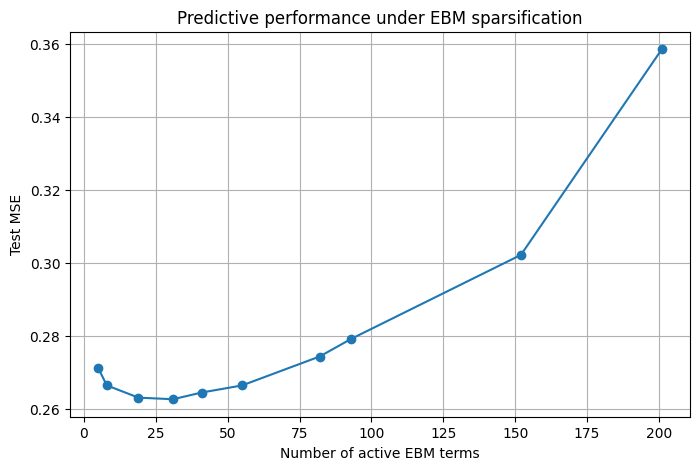

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    final_results["active_terms"],
    final_results["test_mse"],
    marker="o"
)

plt.xlabel("Number of active EBM terms")
plt.ylabel("Test MSE")
plt.title("Predictive performance under EBM sparsification")
plt.grid(True)

plt.show()

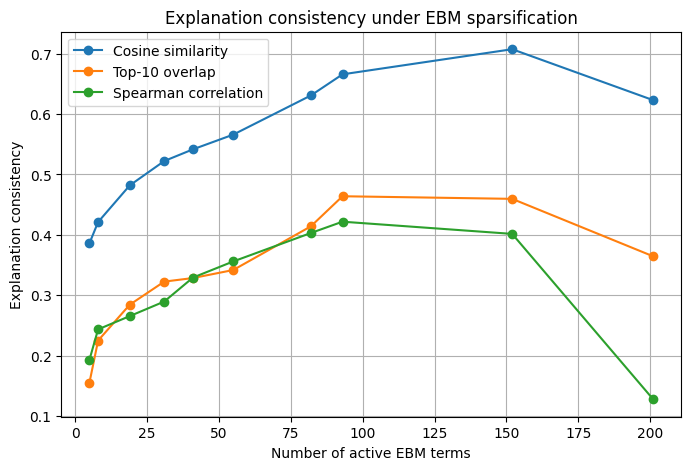

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["active_terms"],
    final_results["mean_cosine"],
    marker="o",
    label="Cosine similarity"
)

plt.plot(
    final_results["active_terms"],
    final_results["top10_overlap"],
    marker="o",
    label="Top-10 overlap"
)

plt.plot(
    final_results["active_terms"],
    final_results["spearman"],
    marker="o",
    label="Spearman correlation"
)

plt.xlabel("Number of active EBM terms")
plt.ylabel("Explanation consistency")
plt.title("Explanation consistency under EBM sparsification")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
baseline_mse = 0.28671030714099377

results_report = final_results.copy()

results_report["mse_change_%"] = (
    (results_report["test_mse"] - baseline_mse)
    / baseline_mse * 100
)

results_report["term_reduction_%"] = (
    (369 - results_report["active_terms"])
    / 369 * 100
)

print(
    results_report[
        [
            "active_terms",
            "term_reduction_%",
            "test_mse",
            "mse_change_%",
            "mean_cosine",
            "top10_overlap",
            "spearman"
        ]
    ].to_string(index=False)
)

 active_terms  term_reduction_%  test_mse  mse_change_%  mean_cosine  top10_overlap  spearman
          201         45.528455  0.358629     25.084221     0.622912        0.36448  0.127934
          152         58.807588  0.302227      5.411916     0.707147        0.45952  0.401531
           93         74.796748  0.279204     -2.618104     0.665589        0.46384  0.421735
           82         77.777778  0.274354     -4.309606     0.630631        0.41408  0.403034
           55         85.094851  0.266420     -7.076811     0.565817        0.34176  0.355944
           41         88.888889  0.264482     -7.753040     0.541493        0.32848  0.329262
           31         91.598916  0.262642     -8.394493     0.522096        0.32256  0.289578
           19         94.850949  0.263074     -8.244004     0.481770        0.28432  0.265460
            8         97.831978  0.266435     -7.071708     0.421113        0.22496  0.243546
            5         98.644986  0.271180     -5.416736     

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

x_test_perturbed = x_test.copy()

# Perturb numerical features by 1% of their training-set standard deviation
for col in x_test.columns:
    std = x_train[col].std()

    if std > 0:
        noise = rng.normal(
            loc=0,
            scale=0.01 * std,
            size=len(x_test)
        )

        x_test_perturbed[col] = x_test_perturbed[col] + noise

print("Original test shape:", x_test.shape)
print("Perturbed test shape:", x_test_perturbed.shape)

Original test shape: (625, 369)
Perturbed test shape: (625, 369)


In [ ]:
original_perturbed_contrib = ebm.eval_terms(x_test_perturbed)

sparse_perturbed_contrib = (
    original_perturbed_contrib * best_lasso.coef_
)

print(original_perturbed_contrib.shape)
print(sparse_perturbed_contrib.shape)

(625, 369)
(625, 369)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

original_stability = []
sparse_stability = []

for i in range(len(x_test)):

    # Original EBM
    sim_original = cosine_similarity(
        X_terms_test[i].reshape(1, -1),
        original_perturbed_contrib[i].reshape(1, -1)
    )[0, 0]

    # Sparse EBM
    sim_sparse = cosine_similarity(
        sparse_contrib[i].reshape(1, -1),
        sparse_perturbed_contrib[i].reshape(1, -1)
    )[0, 0]

    original_stability.append(sim_original)
    sparse_stability.append(sim_sparse)

print(
    "Original EBM stability:",
    np.mean(original_stability)
)

print(
    "Sparse EBM stability:",
    np.mean(sparse_stability)
)

Original EBM stability: 0.9989384678386772
Sparse EBM stability: 0.6973347210032428


In [ ]:
perturbation_levels = [0.001, 0.005, 0.01, 0.02, 0.05]

stability_results = []

for level in perturbation_levels:

    rng = np.random.default_rng(42)

    x_perturbed = x_test.copy()

    for col in x_test.columns:
        std = x_train[col].std()

        if std > 0:
            noise = rng.normal(
                0,
                level * std,
                size=len(x_test)
            )

            x_perturbed[col] = x_perturbed[col] + noise

    # Original EBM explanations
    perturbed_original = ebm.eval_terms(x_perturbed)

    # Sparse explanations
    perturbed_sparse = perturbed_original * best_lasso.coef_

    original_scores = []
    sparse_scores = []

    for i in range(len(x_test)):

        original_scores.append(
            cosine_similarity(
                X_terms_test[i].reshape(1, -1),
                perturbed_original[i].reshape(1, -1)
            )[0, 0]
        )

        sparse_scores.append(
            cosine_similarity(
                sparse_contrib[i].reshape(1, -1),
                perturbed_sparse[i].reshape(1, -1)
            )[0, 0]
        )

    stability_results.append({
        "perturbation": level,
        "original_stability": np.mean(original_scores),
        "sparse_stability": np.mean(sparse_scores)
    })

stability_results = pd.DataFrame(stability_results)

print(stability_results)

   perturbation  original_stability  sparse_stability
0         0.001            0.999704          0.697959
1         0.005            0.999464          0.697575
2         0.010            0.998938          0.697335
3         0.020            0.997496          0.696984
4         0.050            0.991250          0.694689
